In [1]:
!pip install -q pystac-client stackstac

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.4 MB/s eta 0:00:00


In [2]:
from pystac_client import Client

In [3]:
catalog = Client.open(
    'https://earth-search.aws.element84.com/v1'
)

In [5]:
for collection in catalog.get_collections():
  print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [6]:
roi = [45.313893, 36.952326, 45.352848, 36.98608]

In [9]:
search = catalog.search(
    collections = ['sentinel-2-c1-l2a'],
    bbox = roi,
    datetime = '2025',
    query = {'eo:cloud_cover':{'lt': 45}}
)

In [10]:
item = search.item_collection()

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [11]:
len(item)

320

In [13]:
item[0].assets.keys()

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])

In [14]:
import stackstac

In [15]:
ds = stackstac.stack(
    item,
    assets = ['nir','red','scl'],
    bounds_latlon = roi,
    resolution = 10,
    epsg = 3857
)

In [20]:
ds_clean = (
    ds.to_dataset('band')
    .drop_dims('band')
    .reset_coords(drop = True)
    .drop_attrs()
)

In [22]:
cloudy_pixels = ds_clean.scl.isin([3, 8, 9, 10]).astype(int)
veg = ds_clean.scl.isin(4).astype(int).max('time')

In [23]:
ds_mask = ds_clean[['nir','red']].where(cloudy_pixels == 0)
ds_veg = ds_mask.where(veg)

In [24]:
nir = ds_veg['nir']
red = ds_veg['red']
ndvi = ((nir - red) / (nir + red)).rename('ndvi')

In [25]:
ndvi_monthly = ndvi.resample(time = 'M').median('time')

/usr/local/lib/python3.13/dist-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [27]:
ndvi_soil = ndvi_monthly.quantile(0.05, dim = 'time')
ndvi_veg = ndvi_monthly.quantile(0.95, dim = 'time')

In [28]:
fvc = ((ndvi_monthly - ndvi_soil)/(ndvi_veg - ndvi_soil)).rename('fvc')

In [29]:
from dask.diagnostics import ProgressBar

In [33]:
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)

In [34]:
with ProgressBar():
  fvc = fvc.compute()

[########################################] | 100% Completed | 275.64 s


In [40]:
fvc_cor = fvc.clip(0,1) * 100

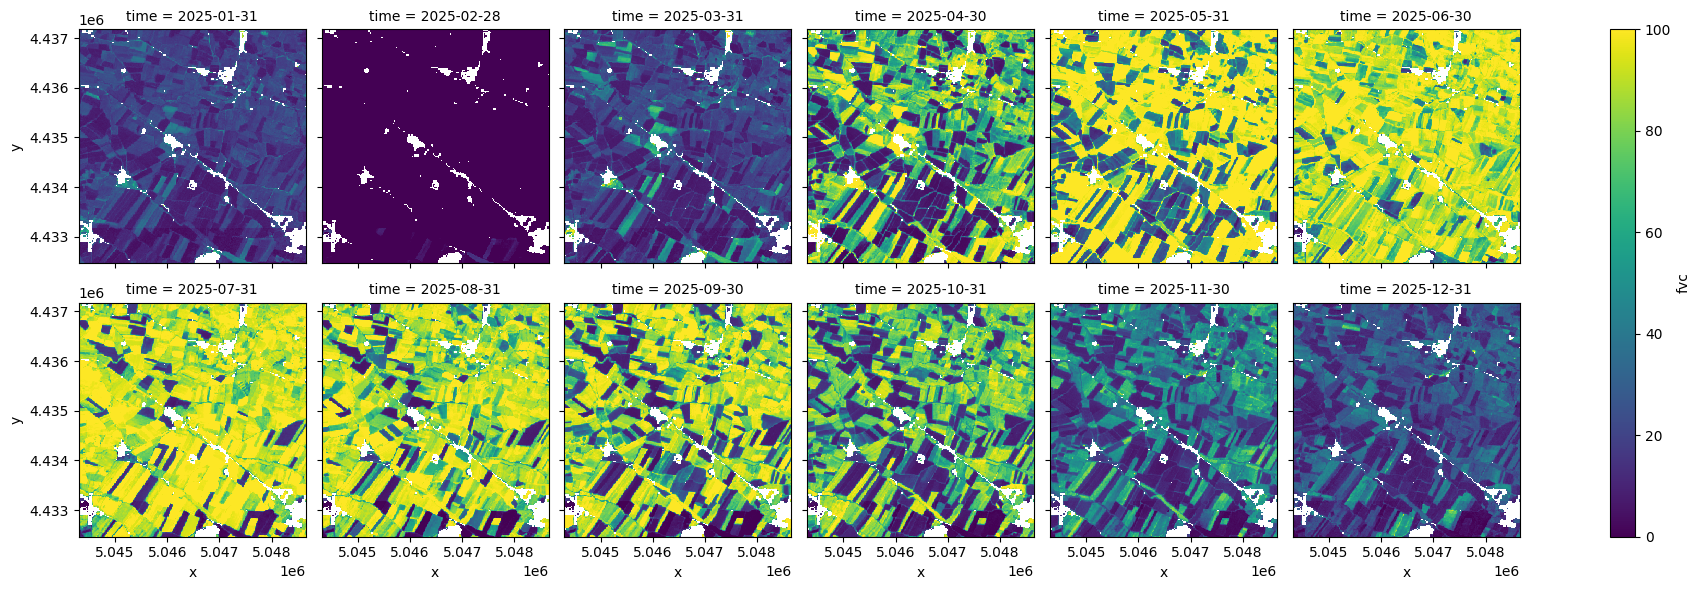

In [41]:
fvc_cor.plot(robust =True, col = 'time', col_wrap = 6)

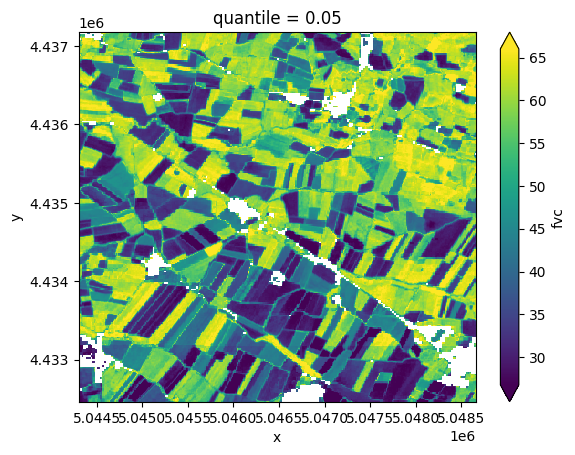

In [42]:
fvc_cor.mean(dim = 'time').plot(robust = True)

<Axes: xlabel='time'>

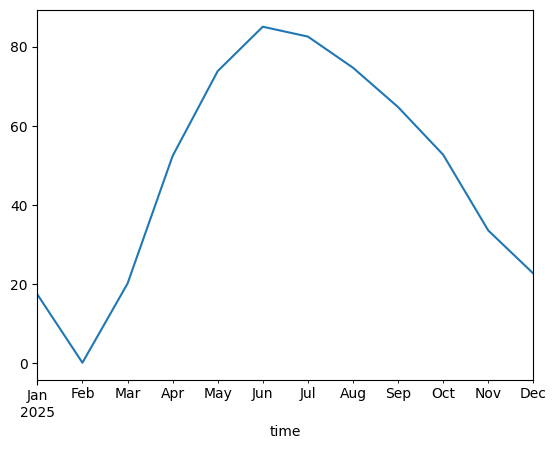

In [45]:
fvc_cor.mean(dim = ['x','y']).to_dataframe()['fvc'].plot()